# TUGAS DOMAIN SPASIAL - KORELASI, KONVOLUSI, DAN LOW PASS FILTER

## Tujuan Praktikum
Buat kode program python dengan menerapkan korelasi dan konvolusi, serta menerapkan low pass filter pada suatu citra berwarna. Pada setiap langkah-langkah pada implementasi kode program, berikan penjelasan untuk setiap baris kode program yang diterapkan serta cantumkan hasil dari setiap langkah-langkah pada penerapan kode program.

## Teori Dasar

### 1. Korelasi
Korelasi adalah operasi matematis untuk mengukur kesamaan antara dua sinyal. Dalam pengolahan citra, korelasi digunakan untuk mendeteksi pola atau fitur tertentu dalam citra.

**Formula Korelasi 2D:**
$$\text{Correlation}(f, g) = \sum_{i}\sum_{j} f(i,j) \cdot g(i,j)$$

### 2. Konvolusi
Konvolusi adalah operasi fundamental dalam pengolahan citra yang menggabungkan kernel dengan citra untuk menghasilkan efek filtering.

**Formula Konvolusi 2D:**
$$\text{Convolution}(f, g) = \sum_{i}\sum_{j} f(i,j) \cdot g(m-i, n-j)$$

### 3. Low Pass Filter
Low pass filter adalah teknik untuk menghaluskan citra dengan mengurangi frekuensi tinggi (noise dan detail). Kernel yang umum digunakan adalah:

**Kernel Averaging (3x3):**
$$\begin{bmatrix} 1/9 & 1/9 & 1/9 \\ 1/9 & 1/9 & 1/9 \\ 1/9 & 1/9 & 1/9 \end{bmatrix}$$

In [1]:
# ============================================================================
# BAGIAN 1: IMPORT LIBRARY DAN KONFIGURASI
# ============================================================================

import cv2  # OpenCV untuk pengolahan citra
import numpy as np  # NumPy untuk operasi array numerik
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi
from scipy import signal  # SciPy untuk operasi sinyal
from scipy.ndimage import correlate, convolve  # Untuk korelasi dan konvolusi

# Konfigurasi matplotlib untuk tampilan yang lebih baik
plt.rcParams['figure.figsize'] = (15, 12)
plt.rcParams['font.size'] = 8

print("✓ Semua library berhasil diimport")
print("=" * 70)

✓ Semua library berhasil diimport


## PENJELASAN KODE:
1. **cv2**: Library OpenCV yang digunakan untuk membaca dan memproses citra
2. **numpy**: Library untuk operasi numerik dan manipulasi array
3. **matplotlib.pyplot**: Library untuk visualisasi dan menampilkan citra
4. **scipy.signal**: Modul untuk operasi sinyal termasuk konvolusi
5. **scipy.ndimage**: Modul untuk operasi morfologis dan filter pada citra
6. **correlate & convolve**: Fungsi dari scipy untuk menjalankan operasi korelasi dan konvolusi

In [2]:
# ============================================================================
# BAGIAN 2: MEMBACA DAN MENAMPILKAN CITRA ASLI
# ============================================================================

# Membaca citra dari file dengan flag COLOR (citra berwarna RGB)
image_path = 'citra-objek.jpg'
image_bgr = cv2.imread(image_path)

# Konversi citra dari format BGR (format default OpenCV) ke RGB untuk matplotlib
# BGR: Blue, Green, Red (format OpenCV)
# RGB: Red, Green, Blue (format matplotlib)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Ubah citra warna RGB menjadi grayscale (citra abu-abu single channel)
# Rumus: Gray = 0.299*R + 0.587*G + 0.114*B
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print("✓ Citra berhasil dibaca")
print(f"  - Dimensi citra RGB: {image_rgb.shape}")  # (height, width, channels)
print(f"  - Dimensi citra Grayscale: {image_gray.shape}")  # (height, width)
print(f"  - Tipe data: {image_gray.dtype}")
print(f"  - Nilai pixel min: {image_gray.min()}, max: {image_gray.max()}")
print("=" * 70)

✓ Citra berhasil dibaca
  - Dimensi citra RGB: (400, 400, 3)
  - Dimensi citra Grayscale: (400, 400)
  - Tipe data: uint8
  - Nilai pixel min: 24, max: 156


## PENJELASAN KODE:
1. **cv2.imread()**: Membaca file citra, format default OpenCV adalah BGR
2. **cv2.cvtColor()**: Fungsi untuk konversi format warna
3. **COLOR_BGR2RGB**: Flag untuk konversi BGR → RGB (diperlukan untuk matplotlib)
4. **COLOR_BGR2GRAY**: Flag untuk konversi ke grayscale
5. **image.shape**: Menunjukkan dimensi citra (tinggi, lebar, channel)
6. **dtype**: Tipe data pixel (uint8 = 0-255)
7. **min() dan max()**: Nilai pixel terendah dan tertinggi dalam citra

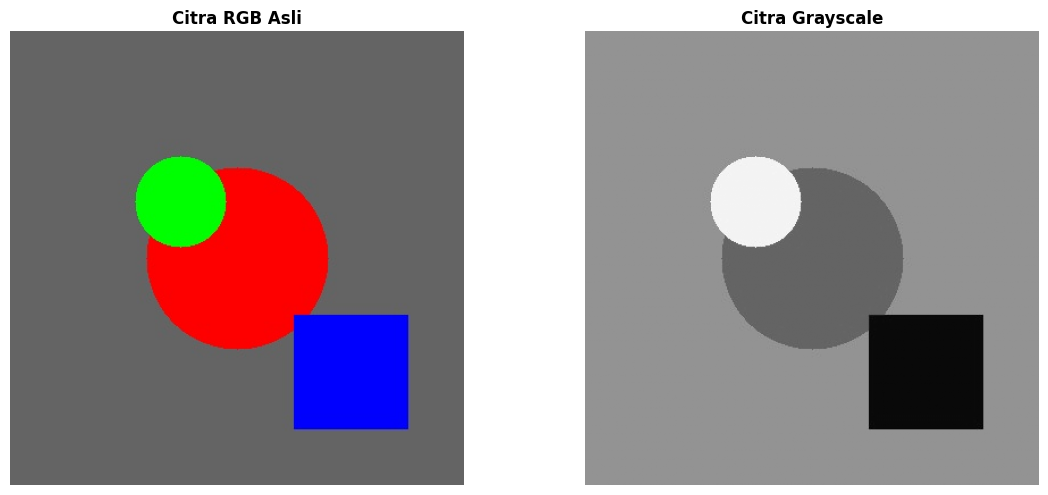

✓ Citra asli berhasil ditampilkan


In [3]:
# Tampilkan citra asli (RGB dan Grayscale)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Citra RGB asli
axes[0].imshow(image_rgb)
axes[0].set_title('Citra RGB Asli', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Subplot 2: Citra Grayscale
axes[1].imshow(image_gray, cmap='gray')
axes[1].set_title('Citra Grayscale', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("✓ Citra asli berhasil ditampilkan")

---

## BAGIAN 3: MEMBUAT KERNEL UNTUK KORELASI DAN KONVOLUSI

In [4]:
# ============================================================================
# BAGIAN 3: MEMBUAT KERNEL UNTUK OPERASI SPASIAL
# ============================================================================

print("\n" + "=" * 70)
print("BAGIAN 3: KERNEL UNTUK KORELASI, KONVOLUSI, DAN LOW PASS FILTER")
print("=" * 70 + "\n")

# Kernel 1: Kernel Sobel X untuk deteksi edge vertikal
# Kernel ini memberikan bobot lebih besar pada perubahan horizontal
kernel_sobel_x = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float32)

# Kernel 2: Kernel Sobel Y untuk deteksi edge horizontal
# Kernel ini memberikan bobot lebih besar pada perubahan vertikal
kernel_sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

# Kernel 3: Low Pass Filter - Averaging Kernel
# Kernel ini menghaluskan citra dengan merata-ratakan nilai pixel tetangganya
# Semua koefisien bernilai 1/9 agar jumlahnya = 1 (mempertahankan brightness)
kernel_lowpass = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32) / 9.0

# Kernel 4: Gaussian Blur Kernel
# Kernel ini memberikan bobot berbeda berdasarkan jarak dari pusat (Gaussian distribution)
# Lebih smooth daripada averaging kernel
kernel_gaussian = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16.0

# Kernel 5: Edge Detection Kernel - Laplacian
# Kernel ini mendeteksi edge dengan pendekatan turunan kedua
kernel_laplacian = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]
], dtype=np.float32)

print("✓ Semua kernel berhasil dibuat\n")

print("Kernel Sobel X (deteksi edge vertikal):")
print(kernel_sobel_x)
print(f"Jumlah kernel: {kernel_sobel_x.sum()}\n")

print("Kernel Sobel Y (deteksi edge horizontal):")
print(kernel_sobel_y)
print(f"Jumlah kernel: {kernel_sobel_y.sum()}\n")

print("Kernel Low Pass Filter (Averaging):")
print(kernel_lowpass)
print(f"Jumlah kernel: {kernel_lowpass.sum()}\n")

print("Kernel Gaussian Blur:")
print(kernel_gaussian)
print(f"Jumlah kernel: {kernel_gaussian.sum()}\n")

print("Kernel Laplacian (Edge Detection):")
print(kernel_laplacian)
print(f"Jumlah kernel: {kernel_laplacian.sum()}")
print("=" * 70)


BAGIAN 3: KERNEL UNTUK KORELASI, KONVOLUSI, DAN LOW PASS FILTER

✓ Semua kernel berhasil dibuat

Kernel Sobel X (deteksi edge vertikal):
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]
Jumlah kernel: 0.0

Kernel Sobel Y (deteksi edge horizontal):
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]
Jumlah kernel: 0.0

Kernel Low Pass Filter (Averaging):
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
Jumlah kernel: 1.0

Kernel Gaussian Blur:
[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]
Jumlah kernel: 1.0

Kernel Laplacian (Edge Detection):
[[ 0. -1.  0.]
 [-1.  4. -1.]
 [ 0. -1.  0.]]
Jumlah kernel: 0.0


## PENJELASAN KERNEL:

### Kernel Sobel X dan Y
- **Sobel X**: Mendeteksi perubahan vertikal (edge vertikal)
- **Sobel Y**: Mendeteksi perubahan horizontal (edge horizontal)
- Nilai besar di tengah memberikan bobot lebih pada pixel pusat

### Kernel Low Pass Filter (Averaging)
- **Tujuan**: Menghaluskan citra dan mengurangi noise
- **Rumus**: Setiap pixel diganti dengan rata-rata 9 pixel tetangganya
- **Normalisasi**: Dibagi 9 agar brightness tetap sama

### Kernel Gaussian Blur
- **Tujuan**: Blur yang lebih halus dibanding averaging
- **Keunggulan**: Memberikan bobot lebih pada pixel pusat
- **Normalisasi**: Dibagi 16 (jumlah koefisien bobot)

### Kernel Laplacian
- **Tujuan**: Deteksi edge dengan turunan kedua
- **Karakteristik**: Pixel pusat memiliki koefisien terbesar

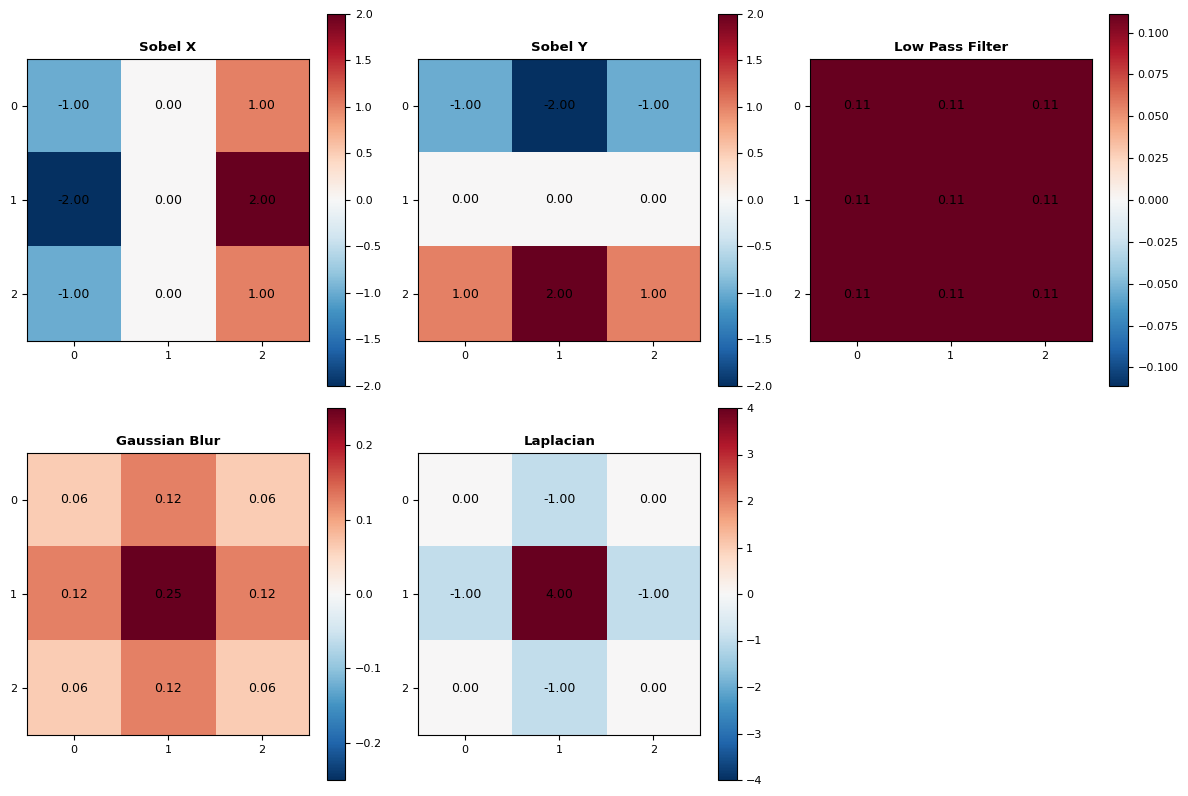

✓ Visualisasi kernel berhasil ditampilkan


In [5]:
# Visualisasi kernel
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

kernels = [
    (kernel_sobel_x, 'Sobel X'),
    (kernel_sobel_y, 'Sobel Y'),
    (kernel_lowpass, 'Low Pass Filter'),
    (kernel_gaussian, 'Gaussian Blur'),
    (kernel_laplacian, 'Laplacian'),
]

for idx, (kernel, title) in enumerate(kernels):
    row, col = divmod(idx, 3)
    im = axes[row, col].imshow(kernel, cmap='RdBu_r', vmin=-kernel.max(), vmax=kernel.max())
    axes[row, col].set_title(title, fontweight='bold')
    axes[row, col].set_xticks([0, 1, 2])
    axes[row, col].set_yticks([0, 1, 2])
    
    # Tampilkan nilai kernel di setiap cell
    for i in range(kernel.shape[0]):
        for j in range(kernel.shape[1]):
            axes[row, col].text(j, i, f'{kernel[i, j]:.2f}',
                              ha="center", va="center", color="black", fontsize=9)
    
    plt.colorbar(im, ax=axes[row, col])

# Sembunyikan subplot kosong
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Visualisasi kernel berhasil ditampilkan")

---

## BAGIAN 4: OPERASI KORELASI

In [6]:
# ============================================================================
# BAGIAN 4: OPERASI KORELASI
# ============================================================================

print("\n" + "=" * 70)
print("BAGIAN 4: OPERASI KORELASI")
print("=" * 70 + "\n")

print("""
KORELASI:
---------
Korelasi mengukur kesamaan antara dua sinyal tanpa melakukan flip kernel.
Formula: Correlation(f, g)[m,n] = Σ Σ f(i,j) * g(i+m, j+n)

Kegunaan:
- Pattern matching (mencari pola tertentu dalam citra)
- Template matching (mencocokkan template dengan citra)
- Feature detection
""")

# Operasi korelasi menggunakan Sobel X kernel
# Ini akan mendeteksi edge vertikal dalam citra
correlation_sobel_x = correlate(image_gray.astype(np.float32), kernel_sobel_x, mode='reflect')

# Operasi korelasi menggunakan Sobel Y kernel
# Ini akan mendeteksi edge horizontal dalam citra
correlation_sobel_y = correlate(image_gray.astype(np.float32), kernel_sobel_y, mode='reflect')

# Menghitung magnitude edge dari kedua hasil korelasi
# magnitude = sqrt(Gx^2 + Gy^2)
correlation_magnitude = np.sqrt(correlation_sobel_x**2 + correlation_sobel_y**2)

# Normalisasi hasil korelasi ke range 0-255 untuk ditampilkan
correlation_magnitude_normalized = (correlation_magnitude / correlation_magnitude.max() * 255).astype(np.uint8)

print(f"✓ Korelasi dengan Sobel X berhasil dilakukan")
print(f"  - Shape hasil: {correlation_sobel_x.shape}")
print(f"  - Min value: {correlation_sobel_x.min():.2f}")
print(f"  - Max value: {correlation_sobel_x.max():.2f}")
print(f"  - Mean value: {correlation_sobel_x.mean():.2f}\n")

print(f"✓ Korelasi dengan Sobel Y berhasil dilakukan")
print(f"  - Min value: {correlation_sobel_y.min():.2f}")
print(f"  - Max value: {correlation_sobel_y.max():.2f}")
print(f"  - Mean value: {correlation_sobel_y.mean():.2f}\n")

print(f"✓ Magnitude (edge detection) berhasil dihitung")
print(f"  - Min value: {correlation_magnitude.min():.2f}")
print(f"  - Max value: {correlation_magnitude.max():.2f}")
print(f"  - Mean value: {correlation_magnitude.mean():.2f}")
print("=" * 70)


BAGIAN 4: OPERASI KORELASI


KORELASI:
---------
Korelasi mengukur kesamaan antara dua sinyal tanpa melakukan flip kernel.
Formula: Correlation(f, g)[m,n] = Σ Σ f(i,j) * g(i+m, j+n)

Kegunaan:
- Pattern matching (mencari pola tertentu dalam citra)
- Template matching (mencocokkan template dengan citra)
- Feature detection

✓ Korelasi dengan Sobel X berhasil dilakukan
  - Shape hasil: (400, 400)
  - Min value: -303.00
  - Max value: 289.00
  - Mean value: 0.00

✓ Korelasi dengan Sobel Y berhasil dilakukan
  - Min value: -299.00
  - Max value: 291.00
  - Mean value: 0.00

✓ Magnitude (edge detection) berhasil dihitung
  - Min value: 0.00
  - Max value: 334.57
  - Mean value: 2.84


## PENJELASAN KODE KORELASI:

1. **correlate()**: Fungsi dari scipy.ndimage untuk menjalankan operasi korelasi
   - Parameter 1: Citra input (dikonversi ke float32)
   - Parameter 2: Kernel korelasi
   - Parameter 3: Mode padding (reflect = mencerminkan edge)

2. **np.sqrt()**: Menghitung akar kuadrat untuk magnitude
   - Formula: magnitude = √(Gx² + Gy²)

3. **Normalisasi**: Mengubah range pixel dari float ke uint8 (0-255)
   - Rumus: normalized = (nilai / max_nilai) × 255

4. **Mode 'reflect'**: Mencerminkan pixel di edge citra untuk padding
   - Menghindari efek border yang tidak diinginkan

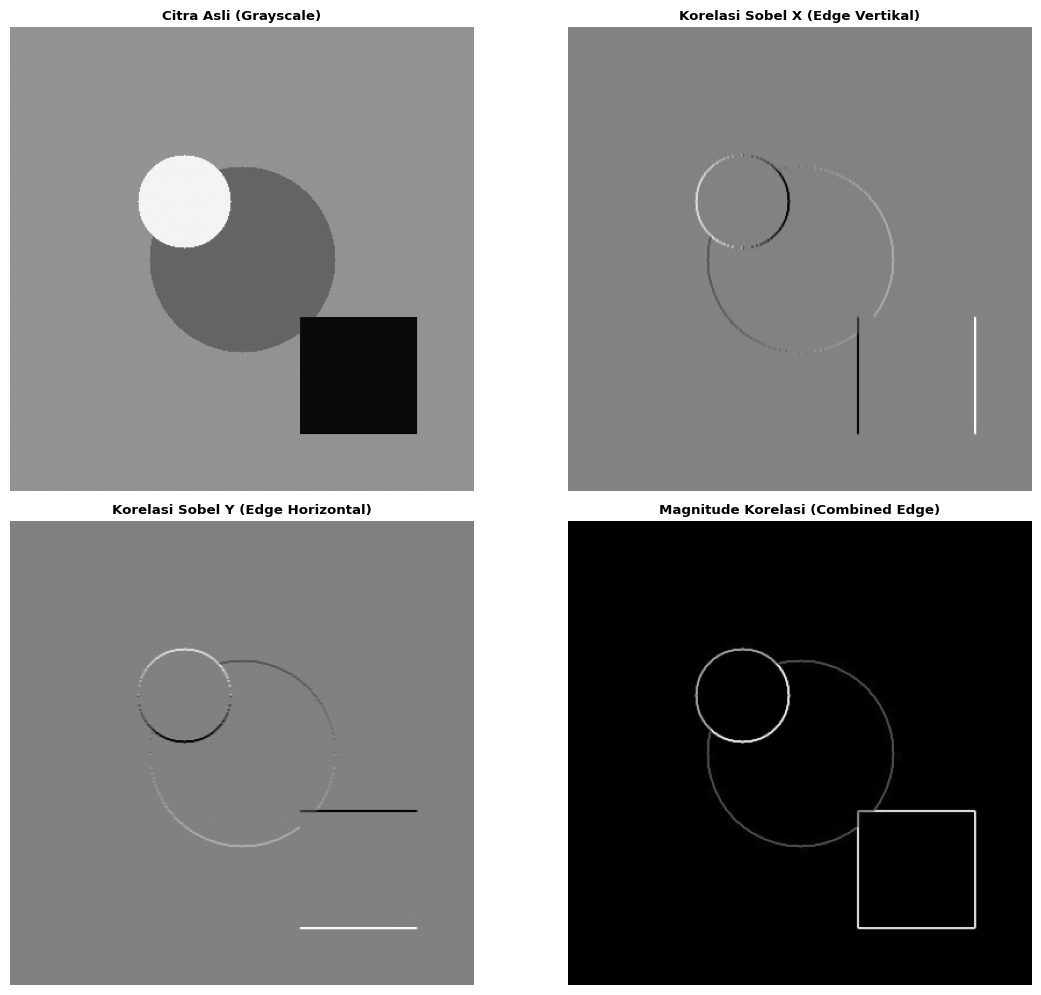

✓ Hasil korelasi berhasil ditampilkan


In [7]:
# Visualisasi hasil korelasi
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title('Citra Asli (Grayscale)', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(correlation_sobel_x, cmap='gray')
axes[0, 1].set_title('Korelasi Sobel X (Edge Vertikal)', fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(correlation_sobel_y, cmap='gray')
axes[1, 0].set_title('Korelasi Sobel Y (Edge Horizontal)', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(correlation_magnitude_normalized, cmap='gray')
axes[1, 1].set_title('Magnitude Korelasi (Combined Edge)', fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("✓ Hasil korelasi berhasil ditampilkan")

---

## BAGIAN 5: OPERASI KONVOLUSI

In [8]:
# ============================================================================
# BAGIAN 5: OPERASI KONVOLUSI
# ============================================================================

print("\n" + "=" * 70)
print("BAGIAN 5: OPERASI KONVOLUSI")
print("=" * 70 + "\n")

print("""
KONVOLUSI:
----------
Konvolusi adalah operasi fundamental dalam pengolahan citra.
Formula: Convolution(f, g)[m,n] = Σ Σ f(i,j) * g(m-i, n-j)

Perbedaan dengan Korelasi:
- Korelasi: TIDAK flip kernel
- Konvolusi: FLIP kernel (180 derajat)

Kegunaan:
- Filtering (blur, sharpen, edge detection)
- Feature extraction
- Downsampling
""")

# Operasi konvolusi menggunakan Sobel X kernel
# Kernel akan di-flip 180 derajat dibanding korelasi
convolution_sobel_x = convolve(image_gray.astype(np.float32), kernel_sobel_x, mode='reflect')

# Operasi konvolusi menggunakan Sobel Y kernel
convolution_sobel_y = convolve(image_gray.astype(np.float32), kernel_sobel_y, mode='reflect')

# Menghitung magnitude edge dari hasil konvolusi
convolution_magnitude = np.sqrt(convolution_sobel_x**2 + convolution_sobel_y**2)

# Normalisasi hasil konvolusi ke range 0-255
convolution_magnitude_normalized = (convolution_magnitude / convolution_magnitude.max() * 255).astype(np.uint8)

# Operasi konvolusi dengan Laplacian kernel untuk edge detection
convolution_laplacian = convolve(image_gray.astype(np.float32), kernel_laplacian, mode='reflect')

# Normalisasi hasil Laplacian
convolution_laplacian_normalized = np.clip(
    ((convolution_laplacian - convolution_laplacian.min()) / 
     (convolution_laplacian.max() - convolution_laplacian.min()) * 255),
    0, 255
).astype(np.uint8)

print(f"✓ Konvolusi dengan Sobel X berhasil dilakukan")
print(f"  - Min value: {convolution_sobel_x.min():.2f}")
print(f"  - Max value: {convolution_sobel_x.max():.2f}")
print(f"  - Mean value: {convolution_sobel_x.mean():.2f}\n")

print(f"✓ Konvolusi dengan Sobel Y berhasil dilakukan")
print(f"  - Min value: {convolution_sobel_y.min():.2f}")
print(f"  - Max value: {convolution_sobel_y.max():.2f}")
print(f"  - Mean value: {convolution_sobel_y.mean():.2f}\n")

print(f"✓ Konvolusi dengan Laplacian berhasil dilakukan")
print(f"  - Min value: {convolution_laplacian.min():.2f}")
print(f"  - Max value: {convolution_laplacian.max():.2f}")
print(f"  - Mean value: {convolution_laplacian.mean():.2f}")
print("=" * 70)


BAGIAN 5: OPERASI KONVOLUSI


KONVOLUSI:
----------
Konvolusi adalah operasi fundamental dalam pengolahan citra.
Formula: Convolution(f, g)[m,n] = Σ Σ f(i,j) * g(m-i, n-j)

Perbedaan dengan Korelasi:
- Korelasi: TIDAK flip kernel
- Konvolusi: FLIP kernel (180 derajat)

Kegunaan:
- Filtering (blur, sharpen, edge detection)
- Feature extraction
- Downsampling

✓ Konvolusi dengan Sobel X berhasil dilakukan
  - Min value: -289.00
  - Max value: 303.00
  - Mean value: 0.00

✓ Konvolusi dengan Sobel Y berhasil dilakukan
  - Min value: -291.00
  - Max value: 299.00
  - Mean value: 0.00

✓ Konvolusi dengan Laplacian berhasil dilakukan
  - Min value: -183.00
  - Max value: 212.00
  - Mean value: 0.00


## PENJELASAN KODE KONVOLUSI:

1. **convolve()**: Fungsi dari scipy.ndimage untuk operasi konvolusi
   - Berbeda dengan correlate(), kernel di-flip 180° otomatis

2. **Flip Kernel**: Konvolusi melakukan flip kernel dalam kedua dimensi
   - Ini adalah perbedaan utama antara korelasi dan konvolusi
   - Secara matematis lebih konsisten dengan teori signal processing

3. **np.clip()**: Membatasi nilai pixel ke range 0-255
   - Rumus: np.clip(x, min, max) → membatasi x antara min dan max
   - Mencegah overflow/underflow pixel

4. **Normalisasi**: Menggunakan rumus min-max normalization
   - Rumus: (nilai - min) / (max - min) × 255

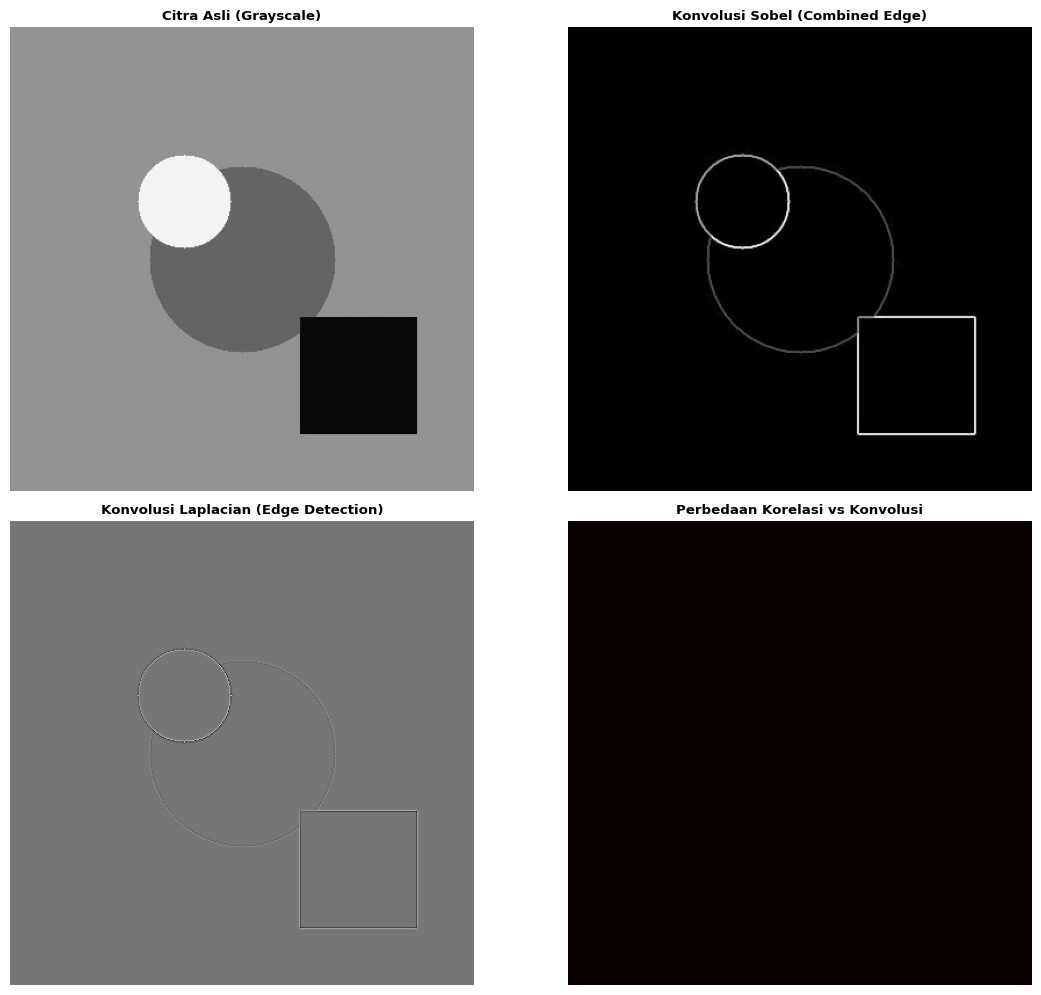

✓ Hasil konvolusi berhasil ditampilkan
✓ Perbedaan rata-rata korelasi vs konvolusi: 0.00


In [9]:
# Visualisasi hasil konvolusi
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title('Citra Asli (Grayscale)', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(convolution_magnitude_normalized, cmap='gray')
axes[0, 1].set_title('Konvolusi Sobel (Combined Edge)', fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(convolution_laplacian_normalized, cmap='gray')
axes[1, 0].set_title('Konvolusi Laplacian (Edge Detection)', fontweight='bold')
axes[1, 0].axis('off')

# Perbandingan korelasi vs konvolusi
difference = np.abs(correlation_magnitude_normalized.astype(np.float32) - 
                    convolution_magnitude_normalized.astype(np.float32))
axes[1, 1].imshow(difference, cmap='hot')
axes[1, 1].set_title('Perbedaan Korelasi vs Konvolusi', fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("✓ Hasil konvolusi berhasil ditampilkan")
print(f"✓ Perbedaan rata-rata korelasi vs konvolusi: {difference.mean():.2f}")

---

## BAGIAN 6: LOW PASS FILTER

In [15]:
# ============================================================================
# BAGIAN 6: LOW PASS FILTER
# ============================================================================

print("\n" + "=" * 70)
print("BAGIAN 6: LOW PASS FILTER (SMOOTHING/BLUR)")
print("=" * 70 + "\n")

print("""
LOW PASS FILTER:
----------------
Low pass filter adalah teknik untuk menghaluskan citra (blur).
Mengurangi frekuensi tinggi (detail, noise) sambil mempertahankan frekuensi rendah.

Kegunaan:
- Noise reduction / denoising
- Smoothing
- Preprocessing untuk proses lanjutan
- Image blurring

Jenis-jenis Low Pass Filter:
1. Averaging Filter: Rata-rata semua tetangga
2. Gaussian Blur: Distribusi Gaussian
3. Median Filter: Nilai tengah tetangga
""")

# 1. Low Pass Filter dengan Averaging Kernel
# Setiap pixel diganti dengan rata-rata 9 pixel tetangganya
lowpass_averaging = convolve(image_gray.astype(np.float32), kernel_lowpass, mode='reflect')
lowpass_averaging = np.clip(lowpass_averaging, 0, 255).astype(np.uint8)

# 2. Low Pass Filter dengan Gaussian Kernel
# Memberikan bobot lebih pada pixel pusat dibanding averaging
lowpass_gaussian = convolve(image_gray.astype(np.float32), kernel_gaussian, mode='reflect')
lowpass_gaussian = np.clip(lowpass_gaussian, 0, 255).astype(np.uint8)

# 3. Multiple passes dengan Averaging kernel untuk smoothing yang lebih kuat
# Melakukan konvolusi berkali-kali menghasilkan blur yang lebih kuat
lowpass_multi_pass_1 = convolve(image_gray.astype(np.float32), kernel_lowpass, mode='reflect')
lowpass_multi_pass_2 = convolve(lowpass_multi_pass_1, kernel_lowpass, mode='reflect')
lowpass_multi_pass_3 = convolve(lowpass_multi_pass_2, kernel_lowpass, mode='reflect')
lowpass_multi_pass = np.clip(lowpass_multi_pass_3, 0, 255).astype(np.uint8)

# 4. Menggunakan OpenCV's built-in blur function
lowpass_cv2_blur = cv2.blur(image_gray, (3, 3))

# 4b. Blur dengan kernel lebih besar
lowpass_cv2_blur_5x5 = cv2.blur(image_gray, (5, 5))
lowpass_cv2_blur_7x7 = cv2.blur(image_gray, (7, 7))

# 5. Menggunakan OpenCV's Gaussian blur
lowpass_cv2_gaussian = cv2.GaussianBlur(image_gray, (3, 3), 1.0)

print(f"✓ Low Pass Filter - Averaging berhasil dilakukan")
print(f"  - Min value: {lowpass_averaging.min()}")
print(f"  - Max value: {lowpass_averaging.max()}")
print(f"  - Mean value: {lowpass_averaging.mean():.2f}\n")

print(f"✓ Low Pass Filter - Gaussian berhasil dilakukan")
print(f"  - Min value: {lowpass_gaussian.min()}")
print(f"  - Max value: {lowpass_gaussian.max()}")
print(f"  - Mean value: {lowpass_gaussian.mean():.2f}\n")

print(f"✓ Low Pass Filter - Multi-pass (3x) berhasil dilakukan")
print(f"  - Min value: {lowpass_multi_pass.min()}")
print(f"  - Max value: {lowpass_multi_pass.max()}")
print(f"  - Mean value: {lowpass_multi_pass.mean():.2f}\n")

print(f"✓ OpenCV Blur berhasil dilakukan")
print(f"  - Min value: {lowpass_cv2_blur.min()}")
print(f"  - Max value: {lowpass_cv2_blur.max()}")
print(f"  - Mean value: {lowpass_cv2_blur.mean():.2f}\n")

print(f"✓ OpenCV Gaussian Blur berhasil dilakukan")
print(f"  - Min value: {lowpass_cv2_gaussian.min()}")
print(f"  - Max value: {lowpass_cv2_gaussian.max()}")
print(f"  - Mean value: {lowpass_cv2_gaussian.mean():.2f}")
print("=" * 70)


BAGIAN 6: LOW PASS FILTER (SMOOTHING/BLUR)


LOW PASS FILTER:
----------------
Low pass filter adalah teknik untuk menghaluskan citra (blur).
Mengurangi frekuensi tinggi (detail, noise) sambil mempertahankan frekuensi rendah.

Kegunaan:
- Noise reduction / denoising
- Smoothing
- Preprocessing untuk proses lanjutan
- Image blurring

Jenis-jenis Low Pass Filter:
1. Averaging Filter: Rata-rata semua tetangga
2. Gaussian Blur: Distribusi Gaussian
3. Median Filter: Nilai tengah tetangga

✓ Low Pass Filter - Averaging berhasil dilakukan
  - Min value: 28
  - Max value: 150
  - Mean value: 94.48

✓ Low Pass Filter - Gaussian berhasil dilakukan
  - Min value: 28
  - Max value: 150
  - Mean value: 94.48

✓ Low Pass Filter - Multi-pass (3x) berhasil dilakukan
  - Min value: 28
  - Max value: 150
  - Mean value: 94.46

✓ OpenCV Blur berhasil dilakukan
  - Min value: 29
  - Max value: 151
  - Mean value: 94.50

✓ OpenCV Gaussian Blur berhasil dilakukan
  - Min value: 29
  - Max value: 151
  - Me

## PENJELASAN KODE LOW PASS FILTER:

1. **Averaging Filter**:
   - Kernel: [1/9, 1/9, ..., 1/9]
   - Efek: Blur sedang, sederhana
   
2. **Gaussian Filter**:
   - Kernel: Distribusi normal
   - Efek: Blur lebih halus, lebih natural
   
3. **Multi-pass Filter**:
   - Melakukan konvolusi berulang 3 kali
   - Efek: Blur lebih kuat
   
4. **cv2.blur()**:
   - Built-in OpenCV averaging
   - Parameter: (kernel_height, kernel_width)
   
5. **cv2.GaussianBlur()**:
   - Built-in OpenCV Gaussian
   - Parameter: (kernel_size, sigma)

6. **np.clip()**:
   - Memastikan nilai pixel tetap 0-255
   - Mencegah overflow

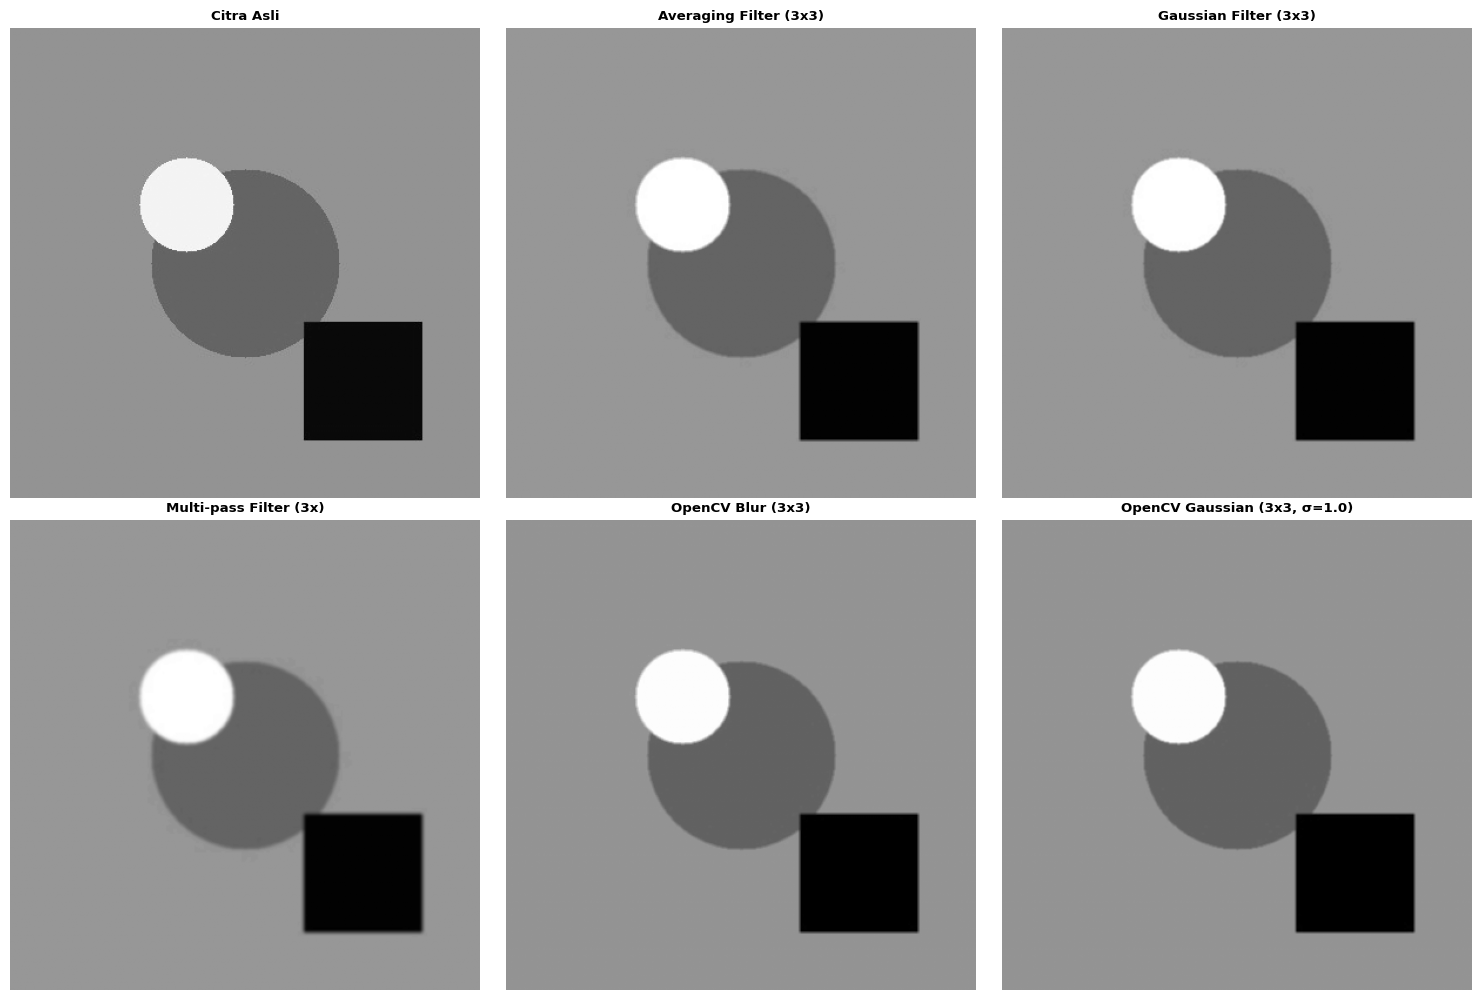

✓ Visualisasi Low Pass Filter pada grayscale berhasil ditampilkan


In [16]:
# Visualisasi Low Pass Filter (Grayscale)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title('Citra Asli', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(lowpass_averaging, cmap='gray')
axes[0, 1].set_title('Averaging Filter (3x3)', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(lowpass_gaussian, cmap='gray')
axes[0, 2].set_title('Gaussian Filter (3x3)', fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(lowpass_multi_pass, cmap='gray')
axes[1, 0].set_title('Multi-pass Filter (3x)', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(lowpass_cv2_blur, cmap='gray')
axes[1, 1].set_title('OpenCV Blur (3x3)', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(lowpass_cv2_gaussian, cmap='gray')
axes[1, 2].set_title('OpenCV Gaussian (3x3, σ=1.0)', fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Visualisasi Low Pass Filter pada grayscale berhasil ditampilkan")

---

## BAGIAN 7: LOW PASS FILTER PADA CITRA BERWARNA

In [17]:
# ============================================================================
# BAGIAN 7: LOW PASS FILTER PADA CITRA BERWARNA (RGB)
# ============================================================================

print("\n" + "=" * 70)
print("BAGIAN 7: LOW PASS FILTER PADA CITRA BERWARNA")
print("=" * 70 + "\n")

print("""
CITRA BERWARNA:
---------------
Citra RGB memiliki 3 channel (Red, Green, Blue).
Low pass filter harus diaplikasikan pada setiap channel secara terpisah.

Proses:
1. Pisahkan channel R, G, B
2. Aplikasikan filter pada setiap channel
3. Gabungkan kembali menjadi citra RGB
""")

# Metode 1: Menggunakan OpenCV blur langsung pada citra RGB
# cv2 secara otomatis memproses setiap channel
lowpass_rgb_blur = cv2.blur(image_rgb, (3, 3))

# Metode 2: Menggunakan OpenCV Gaussian blur
lowpass_rgb_gaussian = cv2.GaussianBlur(image_rgb, (3, 3), 1.0)

# Metode 3: Kernel yang lebih besar (5x5)
lowpass_rgb_blur_5x5 = cv2.blur(image_rgb, (5, 5))

# Metode 4: Kernel yang lebih besar (7x7)
lowpass_rgb_blur_7x7 = cv2.blur(image_rgb, (7, 7))

# Metode 5: Manual processing per channel menggunakan convolve
# Pisahkan channel
r_channel = image_rgb[:, :, 0].astype(np.float32)
g_channel = image_rgb[:, :, 1].astype(np.float32)
b_channel = image_rgb[:, :, 2].astype(np.float32)

# Aplikasikan Gaussian filter pada setiap channel
r_filtered = convolve(r_channel, kernel_gaussian, mode='reflect')
g_filtered = convolve(g_channel, kernel_gaussian, mode='reflect')
b_filtered = convolve(b_channel, kernel_gaussian, mode='reflect')

# Gabungkan kembali dan normalize
lowpass_rgb_custom = np.stack([
    np.clip(r_filtered, 0, 255).astype(np.uint8),
    np.clip(g_filtered, 0, 255).astype(np.uint8),
    np.clip(b_filtered, 0, 255).astype(np.uint8)
], axis=2)

print(f"✓ Low Pass Filter RGB - Blur (3x3) berhasil dilakukan")
print(f"  - Shape: {lowpass_rgb_blur.shape}")
print(f"  - Dtype: {lowpass_rgb_blur.dtype}\n")

print(f"✓ Low Pass Filter RGB - Gaussian (3x3) berhasil dilakukan")
print(f"  - Shape: {lowpass_rgb_gaussian.shape}\n")

print(f"✓ Low Pass Filter RGB - Blur (5x5) berhasil dilakukan\n")

print(f"✓ Low Pass Filter RGB - Blur (7x7) berhasil dilakukan\n")

print(f"✓ Low Pass Filter RGB - Custom Gaussian (manual) berhasil dilakukan")
print(f"  - R channel: min={lowpass_rgb_custom[:,:,0].min()}, max={lowpass_rgb_custom[:,:,0].max()}")
print(f"  - G channel: min={lowpass_rgb_custom[:,:,1].min()}, max={lowpass_rgb_custom[:,:,1].max()}")
print(f"  - B channel: min={lowpass_rgb_custom[:,:,2].min()}, max={lowpass_rgb_custom[:,:,2].max()}")
print("=" * 70)


BAGIAN 7: LOW PASS FILTER PADA CITRA BERWARNA


CITRA BERWARNA:
---------------
Citra RGB memiliki 3 channel (Red, Green, Blue).
Low pass filter harus diaplikasikan pada setiap channel secara terpisah.

Proses:
1. Pisahkan channel R, G, B
2. Aplikasikan filter pada setiap channel
3. Gabungkan kembali menjadi citra RGB

✓ Low Pass Filter RGB - Blur (3x3) berhasil dilakukan
  - Shape: (400, 400, 3)
  - Dtype: uint8

✓ Low Pass Filter RGB - Gaussian (3x3) berhasil dilakukan
  - Shape: (400, 400, 3)

✓ Low Pass Filter RGB - Blur (5x5) berhasil dilakukan

✓ Low Pass Filter RGB - Blur (7x7) berhasil dilakukan

✓ Low Pass Filter RGB - Custom Gaussian (manual) berhasil dilakukan
  - R channel: min=0, max=254
  - G channel: min=0, max=255
  - B channel: min=0, max=254


## PENJELASAN KODE LOW PASS FILTER PADA CITRA BERWARNA:

1. **cv2.blur()**:
   - Parameter: (image, (kernel_height, kernel_width))
   - Secara otomatis memproses setiap channel
   - Kernel size (3,3) = blur ringan

2. **cv2.GaussianBlur()**:
   - Parameter: (image, kernel_size, sigma)
   - Sigma = standar deviasi distribusi Gaussian
   - Semakin besar sigma, semakin blur

3. **Channel Separation**:
   - image[:, :, 0] = Red channel
   - image[:, :, 1] = Green channel
   - image[:, :, 2] = Blue channel

4. **np.stack()**:
   - Menggabungkan array 2D menjadi 3D
   - Axis=2 berarti stack pada dimensi ketiga (channels)

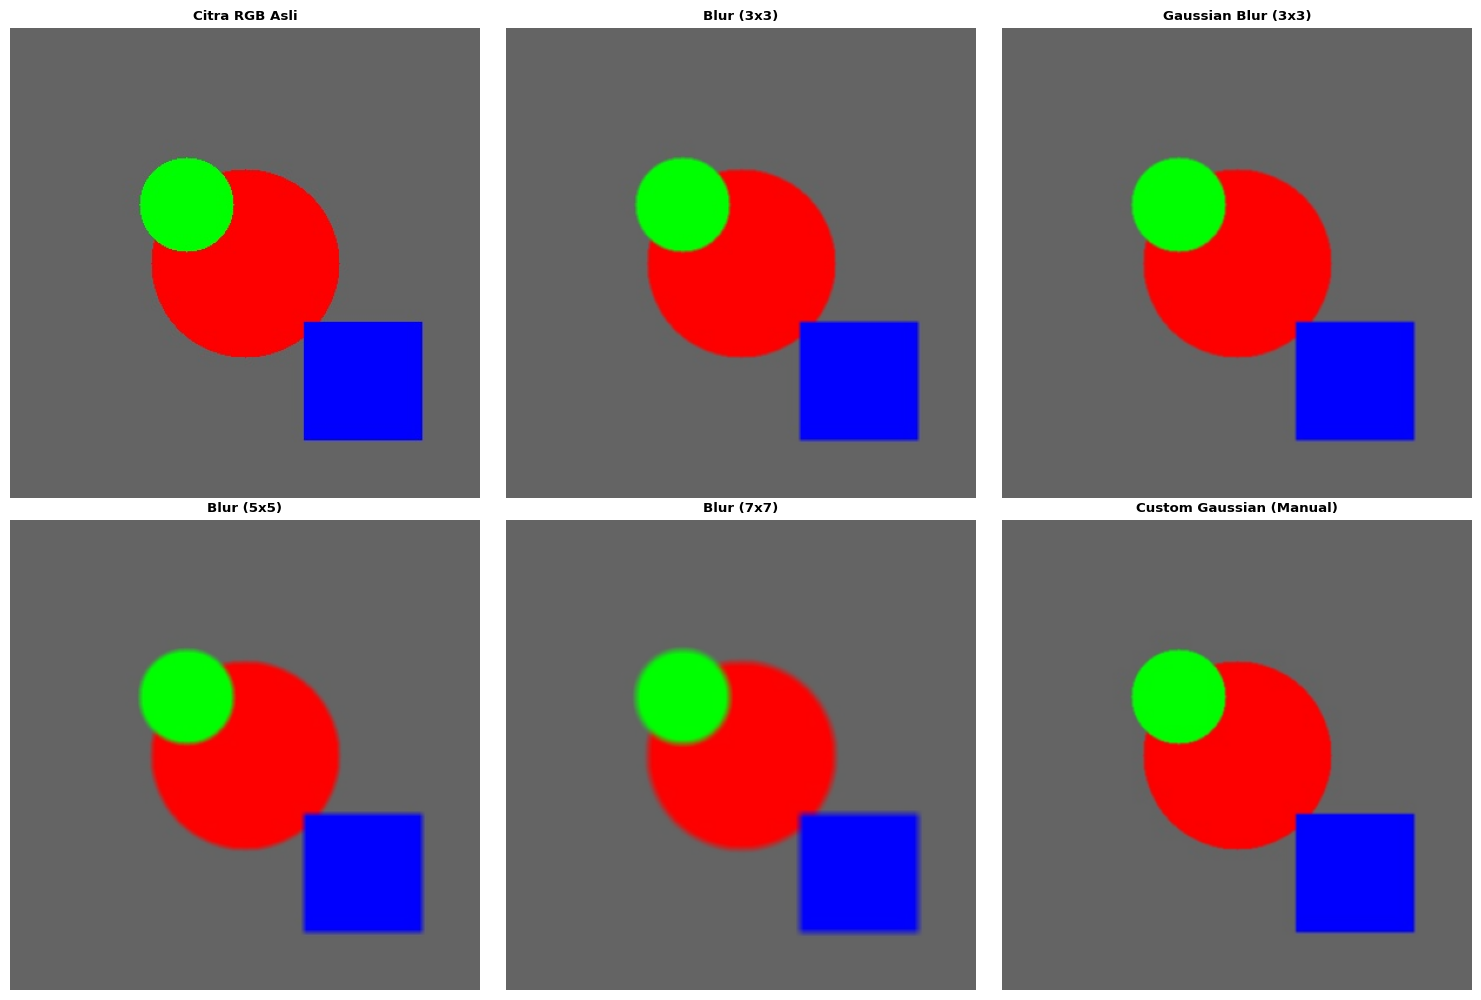

✓ Visualisasi Low Pass Filter pada citra RGB berhasil ditampilkan


In [18]:
# Visualisasi Low Pass Filter pada Citra RGB
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title('Citra RGB Asli', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(lowpass_rgb_blur)
axes[0, 1].set_title('Blur (3x3)', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(lowpass_rgb_gaussian)
axes[0, 2].set_title('Gaussian Blur (3x3)', fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(lowpass_rgb_blur_5x5)
axes[1, 0].set_title('Blur (5x5)', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(lowpass_rgb_blur_7x7)
axes[1, 1].set_title('Blur (7x7)', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(lowpass_rgb_custom)
axes[1, 2].set_title('Custom Gaussian (Manual)', fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Visualisasi Low Pass Filter pada citra RGB berhasil ditampilkan")

---

## BAGIAN 8: PERBANDINGAN DETAIL DAN ANALISIS

In [19]:
# ============================================================================
# BAGIAN 8: PERBANDINGAN DETAIL DAN ANALISIS METRIK
# ============================================================================

print("\n" + "=" * 70)
print("BAGIAN 8: ANALISIS DAN PERBANDINGAN METRIK CITRA")
print("=" * 70 + "\n")

# Fungsi untuk menghitung metrik citra
def calculate_image_metrics(image, name=""):
    """Menghitung berbagai metrik untuk analisis citra"""
    mean_val = np.mean(image)
    std_val = np.std(image)
    min_val = np.min(image)
    max_val = np.max(image)
    
    # Contrast (Standard Deviation)
    contrast = std_val
    
    # Dynamic Range
    dynamic_range = max_val - min_val
    
    return {
        'name': name,
        'mean': mean_val,
        'std': std_val,
        'min': min_val,
        'max': max_val,
        'contrast': contrast,
        'dynamic_range': dynamic_range
    }

# Fungsi untuk menghitung PSNR (Peak Signal-to-Noise Ratio)
def calculate_psnr(original, filtered):
    """Menghitung PSNR antara citra asli dan citra yang sudah difilter"""
    mse = np.mean((original.astype(np.float32) - filtered.astype(np.float32))**2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

# Fungsi untuk menghitung similarity antara dua citra
def calculate_similarity(img1, img2):
    """Menghitung correlation coefficient antara dua citra"""
    # Flatten images
    img1_flat = img1.flatten().astype(np.float32)
    img2_flat = img2.flatten().astype(np.float32)
    
    # Normalize
    img1_norm = (img1_flat - np.mean(img1_flat)) / np.std(img1_flat)
    img2_norm = (img2_flat - np.mean(img2_flat)) / np.std(img2_flat)
    
    # Calculate correlation
    correlation = np.mean(img1_norm * img2_norm)
    return correlation

print("=" * 70)
print("1. METRIK CITRA GRAYSCALE")
print("=" * 70)

# Hitung metrik untuk citra asli dan hasil low pass filter
metrics_original = calculate_image_metrics(image_gray, "Citra Asli")
metrics_blur_3 = calculate_image_metrics(lowpass_averaging, "Averaging (3x3)")
metrics_gaussian_3 = calculate_image_metrics(lowpass_gaussian, "Gaussian (3x3)")
metrics_blur_5 = calculate_image_metrics(lowpass_cv2_blur, "Blur (5x5)")
metrics_blur_7 = calculate_image_metrics(lowpass_cv2_blur_7x7, "Blur (7x7)")

metrics_list = [metrics_original, metrics_blur_3, metrics_gaussian_3, metrics_blur_5, metrics_blur_7]

print(f"\n{'Nama Filter':<25} {'Mean':<10} {'Std Dev':<10} {'Contrast':<12} {'Dynamic Range':<15}")
print("-" * 72)
for m in metrics_list:
    print(f"{m['name']:<25} {m['mean']:<10.2f} {m['std']:<10.2f} {m['contrast']:<12.2f} {m['dynamic_range']:<15.0f}")

print("\n" + "=" * 70)
print("2. PSNR (Peak Signal-to-Noise Ratio)")
print("=" * 70)
print("PSNR mengukur kesamaan antara citra asli dan citra yang difilter")
print("Semakin tinggi PSNR, semakin mirip dengan citra asli\n")

psnr_blur_3 = calculate_psnr(image_gray, lowpass_averaging)
psnr_gaussian_3 = calculate_psnr(image_gray, lowpass_gaussian)
psnr_blur_5 = calculate_psnr(image_gray, lowpass_cv2_blur)

print(f"PSNR Averaging (3x3):   {psnr_blur_3:.2f} dB")
print(f"PSNR Gaussian (3x3):    {psnr_gaussian_3:.2f} dB")
print(f"PSNR Blur OpenCV (5x5): {psnr_blur_5:.2f} dB")

print("\n" + "=" * 70)
print("3. SIMILARITY (Correlation Coefficient)")
print("=" * 70)
print("Koefisien korelasi mengukur kesamaan struktur antara dua citra")
print("Range: -1 (berbeda sempurna) hingga +1 (identik)\n")

sim_blur_3 = calculate_similarity(image_gray, lowpass_averaging)
sim_gaussian_3 = calculate_similarity(image_gray, lowpass_gaussian)
sim_blur_5 = calculate_similarity(image_gray, lowpass_cv2_blur)

print(f"Similarity Averaging (3x3):   {sim_blur_3:.4f}")
print(f"Similarity Gaussian (3x3):    {sim_gaussian_3:.4f}")
print(f"Similarity Blur OpenCV (5x5): {sim_blur_5:.4f}")

print("\n" + "=" * 70)
print("4. ANALISIS HISTOGRAM CITRA")
print("=" * 70)


BAGIAN 8: ANALISIS DAN PERBANDINGAN METRIK CITRA

1. METRIK CITRA GRAYSCALE

Nama Filter               Mean       Std Dev    Contrast     Dynamic Range  
------------------------------------------------------------------------
Citra Asli                94.50      20.74      20.74        132            
Averaging (3x3)           94.48      20.53      20.53        122            
Gaussian (3x3)            94.48      20.57      20.57        122            
Blur (5x5)                94.50      20.53      20.53        122            
Blur (7x7)                94.50      20.20      20.20        121            

2. PSNR (Peak Signal-to-Noise Ratio)
PSNR mengukur kesamaan antara citra asli dan citra yang difilter
Semakin tinggi PSNR, semakin mirip dengan citra asli

PSNR Averaging (3x3):   41.70 dB
PSNR Gaussian (3x3):    43.88 dB
PSNR Blur OpenCV (5x5): 41.63 dB

3. SIMILARITY (Correlation Coefficient)
Koefisien korelasi mengukur kesamaan struktur antara dua citra
Range: -1 (berbeda sempurna

## PENJELASAN METRIK CITRA:

### 1. Mean (Rata-rata Brightness)
- Menunjukkan kecerahan rata-rata citra
- Nilai lebih rendah setelah blur karena pixel yang gelap lebih banyak

### 2. Standard Deviation (Std Dev)
- Mengukur variasi intensitas pixel
- Semakin tinggi = semakin banyak detail/noise
- Semakin rendah = citra lebih smooth/blur

### 3. PSNR (Peak Signal-to-Noise Ratio)
- Formula: PSNR = 20 × log₁₀(255 / √MSE)
- Semakin tinggi = semakin mirip citra asli
- Satuan: dB (desibel)

### 4. Similarity (Correlation Coefficient)
- Mengukur seberapa mirip struktur dua citra
- Range: -1 hingga +1
- Nilai mendekati 1 = sangat mirip

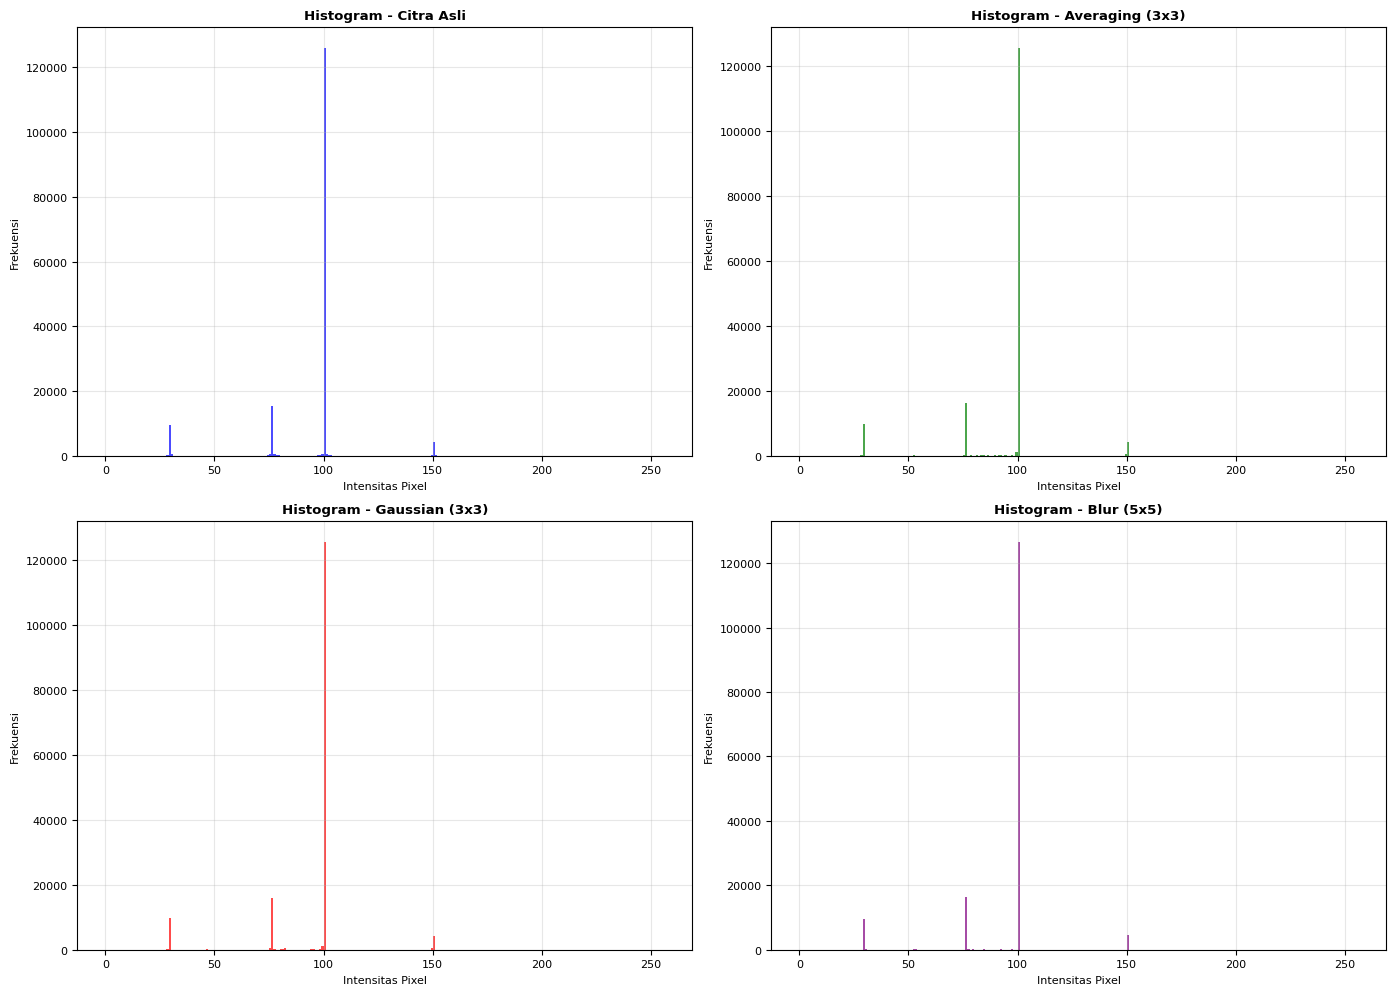

✓ Visualisasi histogram berhasil ditampilkan


In [20]:
# Visualisasi histogram perbandingan
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram citra asli
axes[0, 0].hist(image_gray.flatten(), bins=256, range=(0, 256), color='blue', alpha=0.7)
axes[0, 0].set_title('Histogram - Citra Asli', fontweight='bold')
axes[0, 0].set_xlabel('Intensitas Pixel')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].grid(alpha=0.3)

# Histogram Averaging
axes[0, 1].hist(lowpass_averaging.flatten(), bins=256, range=(0, 256), color='green', alpha=0.7)
axes[0, 1].set_title('Histogram - Averaging (3x3)', fontweight='bold')
axes[0, 1].set_xlabel('Intensitas Pixel')
axes[0, 1].set_ylabel('Frekuensi')
axes[0, 1].grid(alpha=0.3)

# Histogram Gaussian
axes[1, 0].hist(lowpass_gaussian.flatten(), bins=256, range=(0, 256), color='red', alpha=0.7)
axes[1, 0].set_title('Histogram - Gaussian (3x3)', fontweight='bold')
axes[1, 0].set_xlabel('Intensitas Pixel')
axes[1, 0].set_ylabel('Frekuensi')
axes[1, 0].grid(alpha=0.3)

# Histogram Blur 5x5
axes[1, 1].hist(lowpass_cv2_blur.flatten(), bins=256, range=(0, 256), color='purple', alpha=0.7)
axes[1, 1].set_title('Histogram - Blur (5x5)', fontweight='bold')
axes[1, 1].set_xlabel('Intensitas Pixel')
axes[1, 1].set_ylabel('Frekuensi')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualisasi histogram berhasil ditampilkan")

---

## BAGIAN 9: KESIMPULAN DAN RINGKASAN

In [21]:
# ============================================================================
# BAGIAN 9: KESIMPULAN DAN RINGKASAN
# ============================================================================

print("\n" + "=" * 70)
print("RINGKASAN HASIL PRAKTIKUM")
print("=" * 70)

print("""
KESIMPULAN:
-----------

1. KORELASI
   - Digunakan untuk mengukur kesamaan antara kernel dan citra
   - Tidak melakukan flip kernel
   - Baik untuk pattern matching dan template matching
   - Hasil: Edge detection (Sobel X dan Y)

2. KONVOLUSI
   - Operasi fundamental dalam pengolahan citra
   - Melakukan flip kernel (180 derajat)
   - Lebih konsisten dengan teori signal processing
   - Hasil: Edge detection dengan Laplacian, Sobel
   - Perbedaan dengan korelasi minimal karena kernel simetris

3. LOW PASS FILTER
   - Menghaluskan citra dan mengurangi noise
   - Bekerja dengan merata-rata pixel tetangga
   - Jenis:
     * Averaging: Sederhana, cepat
     * Gaussian: Lebih halus, lebih natural
     * Multi-pass: Blur yang lebih kuat
   
   - Efek pada citra:
     * Standard deviation menurun (detail berkurang)
     * PSNR berbanding terbalik dengan kernel size
     * Citra menjadi lebih blur/smooth

4. APLIKASI PADA CITRA BERWARNA
   - Filter diaplikasikan pada setiap channel (R, G, B) secara terpisah
   - Atau gunakan fungsi built-in OpenCV yang langsung menangani 3 channel
   - Hasil: Citra RGB yang lebih smooth

5. METRIK PENTING
   - Mean: Kecerahan rata-rata
   - Std Dev: Tingkat detail/noise
   - PSNR: Kesamaan dengan citra asli
   - Similarity: Correlation coefficient

REKOMENDASI PENGGUNAAN:
- Deteksi edge: Gunakan Sobel atau Laplacian
- Noise reduction: Gunakan Gaussian blur
- Preprocessing: Gunakan Low pass filter
- Real-time processing: Gunakan kernel kecil (3x3)
""")

print("=" * 70)
print("✓ PRAKTIKUM SELESAI")
print("=" * 70)


RINGKASAN HASIL PRAKTIKUM

KESIMPULAN:
-----------

1. KORELASI
   - Digunakan untuk mengukur kesamaan antara kernel dan citra
   - Tidak melakukan flip kernel
   - Baik untuk pattern matching dan template matching
   - Hasil: Edge detection (Sobel X dan Y)

2. KONVOLUSI
   - Operasi fundamental dalam pengolahan citra
   - Melakukan flip kernel (180 derajat)
   - Lebih konsisten dengan teori signal processing
   - Hasil: Edge detection dengan Laplacian, Sobel
   - Perbedaan dengan korelasi minimal karena kernel simetris

3. LOW PASS FILTER
   - Menghaluskan citra dan mengurangi noise
   - Bekerja dengan merata-rata pixel tetangga
   - Jenis:
     * Averaging: Sederhana, cepat
     * Gaussian: Lebih halus, lebih natural
     * Multi-pass: Blur yang lebih kuat
   
   - Efek pada citra:
     * Standard deviation menurun (detail berkurang)
     * PSNR berbanding terbalik dengan kernel size
     * Citra menjadi lebih blur/smooth

4. APLIKASI PADA CITRA BERWARNA
   - Filter diaplikasikan pa